In [1]:
import os
import json
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score
import numpy as np
import pandas as pd

def read_json(path):
    with open(path, 'r', encoding="utf-8") as f:
        data = json.load(f)
    return data

def write_json(data, path):
    if not os.path.exists(os.path.dirname(path)):
        os.makedirs(os.path.dirname(path))
    with open(path, 'w', encoding="utf-8") as f:
        json.dump(data, f, indent=4, ensure_ascii=False)

In [2]:


def forgetting_rate(accuracy_matrix):
    """
    Computes forgetting for each task.
    
    Parameters:
    - accuracy_matrix: 2D numpy array of shape (num_tasks, num_tasks)
      Each row i represents accuracy on task i after training on tasks j=0..T-1
    
    Returns:
    - forgetting: list of forgetting values for each task
    - avg_forgetting: average forgetting across tasks (excluding the last task)
    """
    num_tasks = accuracy_matrix.shape[0]
    forgetting = []

    for i in range(num_tasks - 1):
        max_acc = np.max(accuracy_matrix[i, :i+1])  # Max accuracy before final training
        final_acc = accuracy_matrix[i, -1]          # Accuracy after training on all tasks
        forgetting.append(max_acc - final_acc)

    avg_forgetting = np.mean(forgetting)
    return forgetting, avg_forgetting


In [4]:
# matrices preparation on T5
def compute_forgetting_matrix_t5(input_folder, test_folder):
    results = []
    for i in range(1, 9):
       input_file = f"/Users/sefika/phd_projects/llm-catastrophic-re/last_results/tacred/tacred_oja/{input_folder}/test_pred_{i}.json"
       start=0 
       predictions = read_json(input_file)
       predictions = [item['predict'] for item in predictions]
       
       for id in range(1, i+1):
        test_file = f"/Users/sefika/phd_projects/draft/FS-CRE/data/data/tacred/5way5shot_same_setting_kmeans/5way5shot-test/{test_folder}/task{id}/test.json"
        test_data = read_json(test_file)
        y_true = [item['relation'] for item in test_data]
        y_task = predictions[start:start+len(y_true)]
        acc = accuracy_score(y_true, y_task)*100
        print(f"Task {i} - Task {id} Accuracy: {acc:.4f}")
        print(f"Task {i} - Task {id} Size: {len(y_task)}")
        print(f"Task {i} - Task {id} True Size: {len(y_true)}")

        row = {'base_task':i , 'task':id, 'accuracy':acc}
        
        start += len(y_true)
        results.append(row)
    return results
for run_id in range(1, 6):
    results = compute_forgetting_matrix_t5(
        input_folder=f"model_{run_id}",
        test_folder=f"run{run_id}"
    )
    results
    write_json(results, f"/Users/sefika/phd_projects/llm-catastrophic-re/last_results/tacred/tacred_oja/model_{run_id}_forgetting_matrix.json")


Task 1 - Task 1 Accuracy: 98.1818
Task 1 - Task 1 Size: 770
Task 1 - Task 1 True Size: 770
Task 2 - Task 1 Accuracy: 97.1429
Task 2 - Task 1 Size: 770
Task 2 - Task 1 True Size: 770
Task 2 - Task 2 Accuracy: 98.8156
Task 2 - Task 2 Size: 591
Task 2 - Task 2 True Size: 591
Task 3 - Task 1 Accuracy: 97.6623
Task 3 - Task 1 Size: 770
Task 3 - Task 1 True Size: 770
Task 3 - Task 2 Accuracy: 98.6464
Task 3 - Task 2 Size: 591
Task 3 - Task 2 True Size: 591
Task 3 - Task 3 Accuracy: 99.7191
Task 3 - Task 3 Size: 356
Task 3 - Task 3 True Size: 356
Task 4 - Task 1 Accuracy: 97.1429
Task 4 - Task 1 Size: 770
Task 4 - Task 1 True Size: 770
Task 4 - Task 2 Accuracy: 98.4772
Task 4 - Task 2 Size: 591
Task 4 - Task 2 True Size: 591
Task 4 - Task 3 Accuracy: 99.4382
Task 4 - Task 3 Size: 356
Task 4 - Task 3 True Size: 356
Task 4 - Task 4 Accuracy: 97.2881
Task 4 - Task 4 Size: 295
Task 4 - Task 4 True Size: 295
Task 5 - Task 1 Accuracy: 96.7532
Task 5 - Task 1 Size: 770
Task 5 - Task 1 True Size: 770

In [5]:
def make_matrices(accuracy_matrix):
    """
    Prepares the accuracy matrix for forgetting rate computation.
    
    Parameters:
    - accuracy_matrix: 2D numpy array of shape (num_tasks, num_tasks)
      Each row i represents accuracy on task i after training on tasks j=0..T-1
    
    Returns:
    - prepared_matrix: 2D numpy array of shape (num_tasks, num_tasks)
      The prepared matrix for forgetting rate computation
    """
    # Pivot the accuracy matrix
    prepared_matrix = accuracy_matrix.pivot(index='base_task', columns='task', values='accuracy').fillna(0).values
    return prepared_matrix.T


In [6]:
# Forgetting rate for Oja's rule
forgetting_rates, avg_forgetting_list = [], []
for run_id in range(1, 6):
    acc_path = f"/Users/sefika/phd_projects/llm-catastrophic-re/last_results/tacred/tacred_oja/model_{run_id}_forgetting_matrix.json"
    accuracy_matrix = pd.read_json(acc_path)
    accuracy_matrix = make_matrices(accuracy_matrix)
    forgetting, avg_forgetting = forgetting_rate(accuracy_matrix)
    # print(accuracy_matrix)
    print(f"Run {run_id} - Forgetting: {forgetting}")
    print(f"Run {run_id} - Average Forgetting: {avg_forgetting}")
    row = {'run_id': run_id, 'forgetting': forgetting, 'avg_forgetting': avg_forgetting}
    forgetting_rates.append(row)
    avg_forgetting_list.append(avg_forgetting)
    

Run 1 - Forgetting: [1.6883116883116855, 2.538071065989854, 0.0, 3.7288135593220204, -1.9955654101995606, 0.9398496240601446, 0.4524886877828038]
Run 1 - Average Forgetting: 1.0502813164667069
Run 2 - Forgetting: [0.6578947368421098, 14.563106796116514, 5.617977528089895, 0.15873015873017948, 5.656565656565661, 0.0, 1.8796992481203034]
Run 2 - Average Forgetting: 4.076282017780666
Run 3 - Forgetting: [0.0, 1.1342155009451886, 6.09480812641084, 4.948805460750862, 4.301075268817215, -1.7921146953405014, 0.13623978201636078]
Run 3 - Average Forgetting: 2.1175756347999948
Run 4 - Forgetting: [1.0344827586206833, 0.568181818181813, 14.594594594594597, 19.047619047619044, 0.19880715705765795, -0.8733624454148554, 1.8115942028985472]
Run 4 - Average Forgetting: 5.197416733365356
Run 5 - Forgetting: [3.1034482758620783, 0.8344923504867978, 0.22935779816512536, 0.0, 11.494252873563227, -2.363184079601993, 0.2941176470588118]
Run 5 - Average Forgetting: 1.9417835522191496


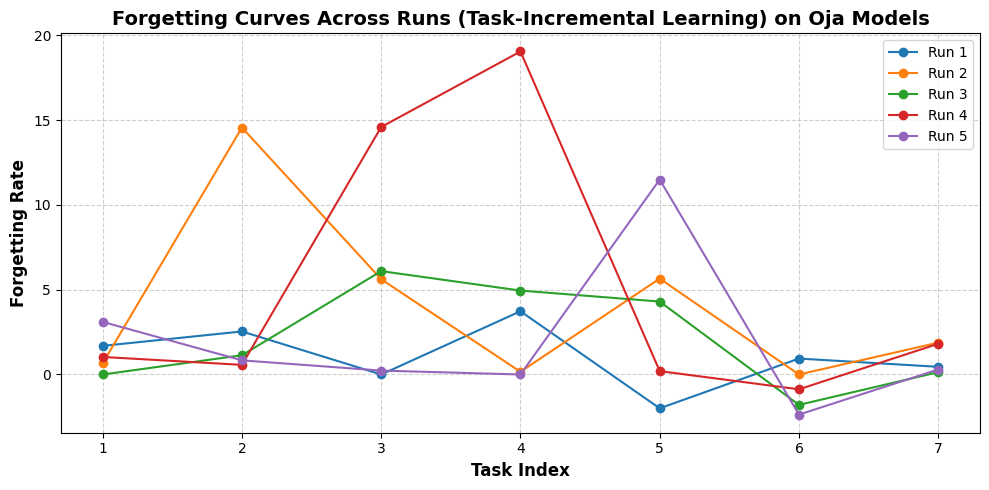

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Your data
data = forgetting_rates
# Prepare data
df = pd.DataFrame([
    {"Run": d["run_id"], "Task": i + 1, "Forgetting": f}
    for d in data for i, f in enumerate(d["forgetting"])
])
avg_df = pd.DataFrame({
    "Run": [d["run_id"] for d in data],
    "Average Forgetting": [d["avg_forgetting"] for d in data]
})

# Plot forgetting per task
plt.figure(figsize=(10, 5))
for run_id, group in df.groupby("Run"):
    plt.plot(group["Task"], group["Forgetting"], marker="o", label=f"Run {run_id}")
plt.xlabel("Task Index", fontsize=12, weight='bold')
plt.ylabel("Forgetting Rate", fontsize=12, weight='bold')
plt.title("Forgetting Curves Across Runs (Task-Incremental Learning) on Oja Models", fontsize=14, weight='bold')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("tacred_oja_forgetting_curves.pdf", dpi=300)
plt.show()


In [8]:

print("Average Forgetting across runs:", np.mean(avg_forgetting_list))
print("Std Average Rates across runs:", np.std(avg_forgetting_list))

Average Forgetting across runs: 2.876667850926375
Std Average Rates across runs: 1.523867903885888


In [9]:
# 
forgetting_rates, avg_forgetting_list = [], []
for run_id in range(1, 6):
    acc_path = f"/Users/sefika/phd_projects/llm-catastrophic-re/last_results/tacred/baseline/baseline_{run_id}_forgetting_matrix.json"
    accuracy_matrix = pd.read_json(acc_path)
    accuracy_matrix = make_matrices(accuracy_matrix)
    forgetting, avg_forgetting = forgetting_rate(accuracy_matrix)
    # print(accuracy_matrix)
    print(f"Run {run_id} - Forgetting: {forgetting}")
    print(f"Run {run_id} - Average Forgetting: {avg_forgetting}")
    row = {'run_id': run_id, 'forgetting': forgetting, 'avg_forgetting': avg_forgetting}
    forgetting_rates.append(row)
    avg_forgetting_list.append(avg_forgetting)
print("Average Forgetting across runs:", np.mean(avg_forgetting_list))
print("Std Average Rates across runs:", np.std(avg_forgetting_list))

Run 1 - Forgetting: [0.0, 0.005076142131979933, 0.0, 0.0, -0.044345898004434, 0.02067669172932296, 0.009049773755655965]
Run 1 - Average Forgetting: -0.001363327198210735
Run 2 - Forgetting: [0.0043859649122810485, 0.08090614886731395, -0.016853932584268927, 0.0015873015873009155, 0.12929292929292902, 0.015384615384615996, -0.022556390977443996]
Run 2 - Average Forgetting: 0.027449519497532573
Run 3 - Forgetting: [-0.01578947368421002, 0.011342155009452015, 0.09480812641083503, -0.0068259385665528916, 0.11021505376343999, 0.010752688172043001, 0.010899182561308063]
Run 3 - Average Forgetting: 0.030771684809473596
Run 4 - Forgetting: [0.0008620689655169933, -0.00568181818181801, 0.072972972972973, 0.275793650793651, 0.09542743538767406, -0.004366812227075023, -0.014492753623187915]
Run 4 - Average Forgetting: 0.0600735348696763
Run 5 - Forgetting: [0.08965517241379306, 0.05702364394993009, -0.09403669724770702, 0.012578616352200922, 0.16666666666666707, -0.03606965174129395, 0.079411764

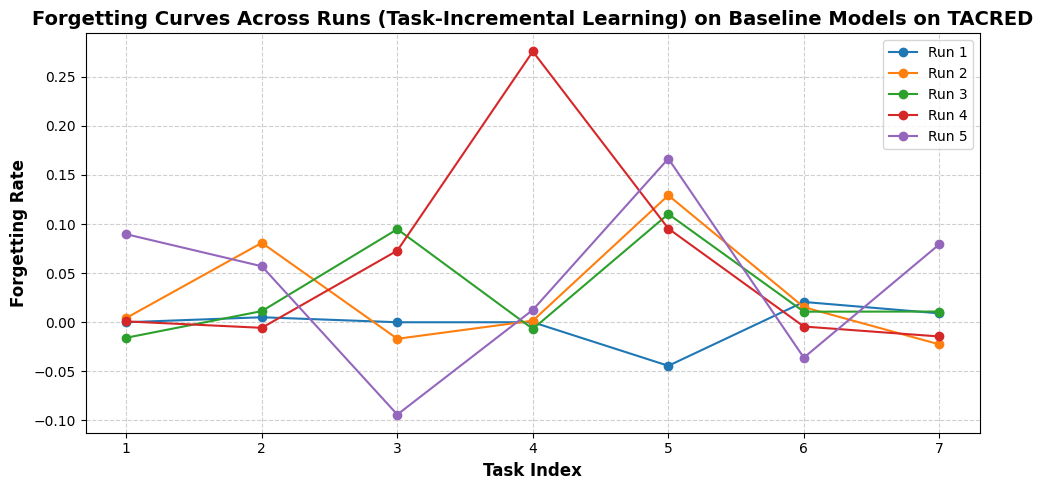

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Your data
data = forgetting_rates
# Prepare data
df = pd.DataFrame([
    {"Run": d["run_id"], "Task": i + 1, "Forgetting": f}
    for d in data for i, f in enumerate(d["forgetting"])
])
avg_df = pd.DataFrame({
    "Run": [d["run_id"] for d in data],
    "Average Forgetting": [d["avg_forgetting"] for d in data]
})

# Plot forgetting per task
plt.figure(figsize=(10, 5))
for run_id, group in df.groupby("Run"):
    plt.plot(group["Task"], group["Forgetting"], marker="o", label=f"Run {run_id}")
plt.xlabel("Task Index", fontsize=12, weight='bold')
plt.ylabel("Forgetting Rate", fontsize=12, weight='bold')
plt.title("Forgetting Curves Across Runs (Task-Incremental Learning) on Baseline Models on TACRED", fontsize=14, weight='bold')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("tacred_baseline_forgetting_curves.pdf", dpi=300)
plt.show()


In [11]:
# Forgetting rate for Oja's rule
forgetting_rates, avg_forgetting_list = [], []
for run_id in range(1, 6):
    acc_path = f"/Users/sefika/phd_projects/llm-catastrophic-re/last_results/tacred/ewc_corrected_tacred_100/model_{run_id}_forgetting_matrix.json"
    accuracy_matrix = pd.read_json(acc_path)
    accuracy_matrix = make_matrices(accuracy_matrix)
    forgetting, avg_forgetting = forgetting_rate(accuracy_matrix)
    # print(accuracy_matrix)
    print(f"Run {run_id} - Forgetting: {forgetting}")
    print(f"Run {run_id} - Average Forgetting: {avg_forgetting}")
    row = {'run_id': run_id, 'forgetting': forgetting, 'avg_forgetting': avg_forgetting}
    forgetting_rates.append(row)
    avg_forgetting_list.append(avg_forgetting)
print("Average Forgetting across runs:", np.mean(avg_forgetting_list))
print("Std Average Rates across runs:", np.std(avg_forgetting_list))

Run 1 - Forgetting: [0.019480519480520098, 0.08798646362098195, 0.002808988764045006, 0.01355932203389898, 0.022172949002217, -0.07706766917293195, 0.004524886877828038]
Run 1 - Average Forgetting: 0.010495065800937018
Run 2 - Forgetting: [0.006578947368421018, 0.14886731391585795, 0.056179775280899014, 0.0015873015873010266, 0.05656565656565604, 0.0, 0.018796992481202035]
Run 2 - Average Forgetting: 0.04122514102847673
Run 3 - Forgetting: [0.0, 0.011342155009451016, 0.05869074492099391, 0.049488054607507936, 0.043010752688172005, -0.017921146953404965, 0.0]
Run 3 - Average Forgetting: 0.020658651467531413
Run 4 - Forgetting: [0.010344827586207028, 0.00568181818181801, 0.15135135135135203, 0.19047619047619002, 0.001988071570576011, -0.008733624454148936, 0.018115942028986032]
Run 4 - Average Forgetting: 0.05274636810585431
Run 5 - Forgetting: [0.031034482758621085, 0.00834492350486804, 0.002293577981651085, 0.0, 0.11494252873563193, -0.023631840796019987, 0.002941176470588003]
Run 5 - 

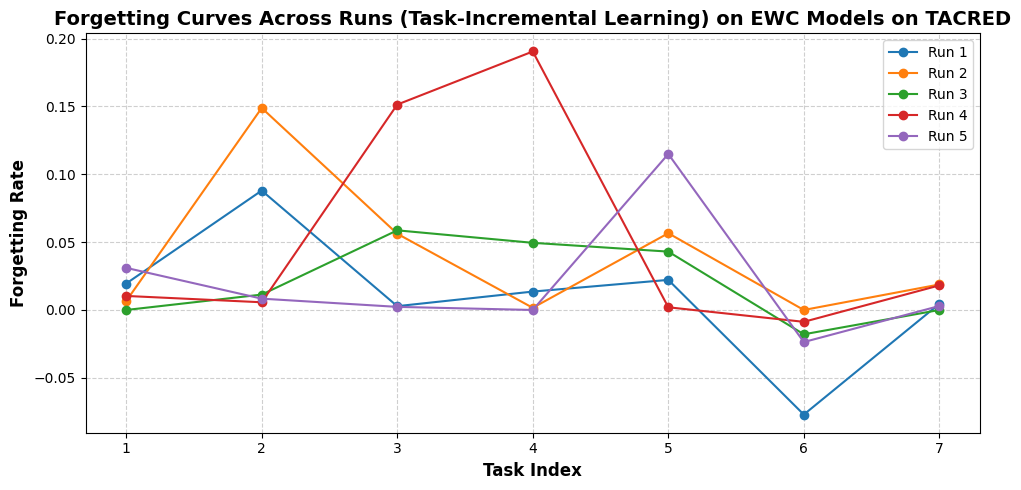

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Your data
data = forgetting_rates
# Prepare data
df = pd.DataFrame([
    {"Run": d["run_id"], "Task": i + 1, "Forgetting": f}
    for d in data for i, f in enumerate(d["forgetting"])
])
avg_df = pd.DataFrame({
    "Run": [d["run_id"] for d in data],
    "Average Forgetting": [d["avg_forgetting"] for d in data]
})

# Plot forgetting per task
plt.figure(figsize=(10, 5))
for run_id, group in df.groupby("Run"):
    plt.plot(group["Task"], group["Forgetting"], marker="o", label=f"Run {run_id}")
plt.xlabel("Task Index", fontsize=12, weight='bold')
plt.ylabel("Forgetting Rate", fontsize=12, weight='bold')
plt.title("Forgetting Curves Across Runs (Task-Incremental Learning) on EWC Models on TACRED", fontsize=14, weight='bold')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("tacred_ewc_forgetting_curves.pdf", dpi=300)
plt.show()


In [13]:
# Forgetting rate for Oja's rule
forgetting_rates, avg_forgetting_list = [], []
for run_id in range(1, 6):
    acc_path = f"/Users/sefika/phd_projects/llm-catastrophic-re/last_results/tacred/mas_correct_tacred/model_{run_id}_forgetting_matrix.json"
    accuracy_matrix = pd.read_json(acc_path)
    accuracy_matrix = make_matrices(accuracy_matrix)
    forgetting, avg_forgetting = forgetting_rate(accuracy_matrix)
    # print(accuracy_matrix)
    print(f"Run {run_id} - Forgetting: {forgetting}")
    print(f"Run {run_id} - Average Forgetting: {avg_forgetting}")
    row = {'run_id': run_id, 'forgetting': forgetting, 'avg_forgetting': avg_forgetting}
    forgetting_rates.append(row)
    avg_forgetting_list.append(avg_forgetting)
print("Average Forgetting across runs:", np.mean(avg_forgetting_list))
print("Std Average Rates across runs:", np.std(avg_forgetting_list))

Run 1 - Forgetting: [0.0, 0.006768189509307021, 0.005617977528090012, 0.023728813559322992, 0.022172949002218, 0.028195488721803996, -0.009049773755655965]
Run 1 - Average Forgetting: 0.011061949223583722
Run 2 - Forgetting: [0.006578947368421018, 0.14886731391585795, 0.056179775280899014, 0.0015873015873010266, 0.05656565656565604, 0.0, 0.018796992481202035]
Run 2 - Average Forgetting: 0.04122514102847673
Run 3 - Forgetting: [0.0, 0.011342155009451016, 0.05869074492099391, 0.049488054607507936, 0.043010752688172005, -0.017921146953404965, 0.0]
Run 3 - Average Forgetting: 0.020658651467531413
Run 4 - Forgetting: [0.010344827586207028, 0.00568181818181801, 0.15135135135135203, 0.19047619047619002, 0.001988071570576011, -0.008733624454148936, 0.018115942028986032]
Run 4 - Average Forgetting: 0.05274636810585431
Run 5 - Forgetting: [0.031034482758621085, 0.00834492350486804, 0.002293577981651085, 0.0, 0.11494252873563193, -0.023631840796019987, 0.002941176470588003]
Run 5 - Average Forget

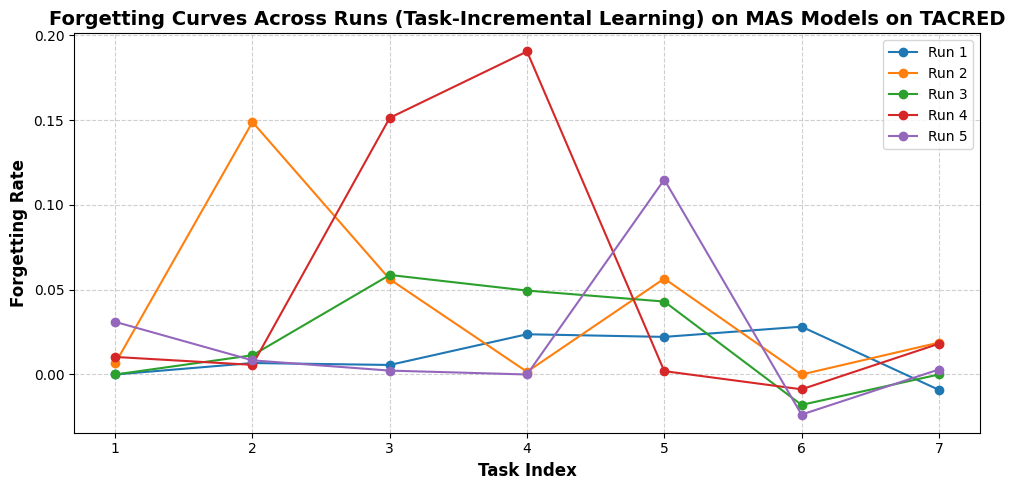

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Your data
data = forgetting_rates
# Prepare data
df = pd.DataFrame([
    {"Run": d["run_id"], "Task": i + 1, "Forgetting": f}
    for d in data for i, f in enumerate(d["forgetting"])
])
avg_df = pd.DataFrame({
    "Run": [d["run_id"] for d in data],
    "Average Forgetting": [d["avg_forgetting"] for d in data]
})

# Plot forgetting per task
plt.figure(figsize=(10, 5))
for run_id, group in df.groupby("Run"):
    plt.plot(group["Task"], group["Forgetting"], marker="o", label=f"Run {run_id}")
plt.xlabel("Task Index", fontsize=12, weight='bold')
plt.ylabel("Forgetting Rate", fontsize=12, weight='bold')
plt.title("Forgetting Curves Across Runs (Task-Incremental Learning) on MAS Models on TACRED", fontsize=14, weight='bold')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("tacred_mas_forgetting_curves.pdf", dpi=300)
plt.show()


In [15]:
# Forgetting rate for Oja's rule
forgetting_rates, avg_forgetting_list = [], []
for run_id in range(1, 6):
    acc_path = f"/Users/sefika/phd_projects/llm-catastrophic-re/last_results/tacred/si_tacred_flan_random/model_{run_id}_forgetting_matrix.json"
    accuracy_matrix = pd.read_json(acc_path)
    accuracy_matrix = make_matrices(accuracy_matrix)
    forgetting, avg_forgetting = forgetting_rate(accuracy_matrix)
    # print(accuracy_matrix)
    print(f"Run {run_id} - Forgetting: {forgetting}")
    print(f"Run {run_id} - Average Forgetting: {avg_forgetting}")
    row = {'run_id': run_id, 'forgetting': forgetting, 'avg_forgetting': avg_forgetting}
    forgetting_rates.append(row)
    avg_forgetting_list.append(avg_forgetting)
print("Average Forgetting across runs:", np.mean(avg_forgetting_list))
print("Std Average Rates across runs:", np.std(avg_forgetting_list))

Run 1 - Forgetting: [0.0012987012987010216, 0.042301184433163996, 0.0, 0.057627118644068, 0.017738359201773912, 0.009398496240600962, 0.004524886877827927]
Run 1 - Average Forgetting: 0.018984106670876546
Run 2 - Forgetting: [0.0, 0.14886731391585795, -0.016853932584270037, 0.004761904761905078, 0.044444444444444065, 0.05384615384615399, 0.060150375939850065]
Run 2 - Average Forgetting: 0.04217375147484873
Run 3 - Forgetting: [0.01578947368421102, 0.20415879017013205, 0.020316027088035926, 0.023890784982934954, 0.13709677419354893, 0.014336917562723928, -0.0013623978201640075]
Run 3 - Average Forgetting: 0.05917519569448897
Run 4 - Forgetting: [0.011206896551724022, 0.14204545454545503, -0.005405405405405017, 0.23809523809523803, 0.03180914512922506, 0.017467248908297095, -0.007246376811594013]
Run 4 - Average Forgetting: 0.06113888585899146
Run 5 - Forgetting: [0.04827586206896506, 0.006954102920723071, -0.022935779816514068, 0.0, 0.11494252873563204, 0.011194029850747023, 0.008823529

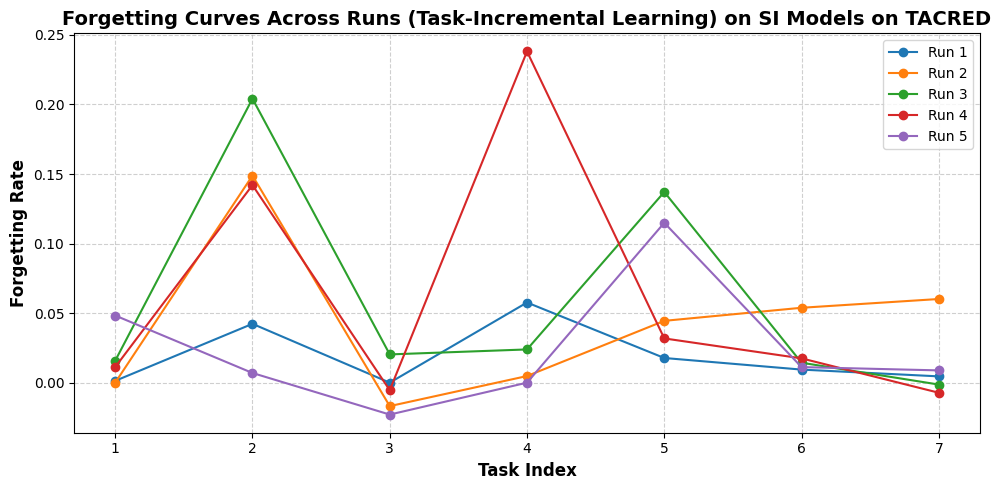

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Your data
data = forgetting_rates
# Prepare data
df = pd.DataFrame([
    {"Run": d["run_id"], "Task": i + 1, "Forgetting": f}
    for d in data for i, f in enumerate(d["forgetting"])
])
avg_df = pd.DataFrame({
    "Run": [d["run_id"] for d in data],
    "Average Forgetting": [d["avg_forgetting"] for d in data]
})

# Plot forgetting per task
plt.figure(figsize=(10, 5))
for run_id, group in df.groupby("Run"):
    plt.plot(group["Task"], group["Forgetting"], marker="o", label=f"Run {run_id}")
plt.xlabel("Task Index", fontsize=12, weight='bold')
plt.ylabel("Forgetting Rate", fontsize=12, weight='bold')
plt.title("Forgetting Curves Across Runs (Task-Incremental Learning) on SI Models on TACRED", fontsize=14, weight='bold')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("tacred_si_forgetting_curves.pdf", dpi=300)
plt.show()
